In [290]:
import pandas as pd
import geopandas as gpd
import esda
import matplotlib.pyplot as plt
from libpysal import graph

import seaborn as sns

In [291]:
skolky_body = gpd.read_file("geometrie/body_skolky.shp").set_index("RED_IZO")
skolky_body.columns

Index(['IČO', 'Zřizovate', 'Území', 'Kraj', 'Okres_Obvo', 'Správní_', 'ORP',
       'Název_ORP', 'Plný_náz', 'Zkrácený', 'Ulice', 'Č__p_', 'Č__or_',
       'Část_obc', 'PSČ', 'Místo', 'WWW', 'ZUJ', 'monthly_fe', 'meals',
       'identifica', 'X', 'Y', 'monthly__1', 'geometry'],
      dtype='object')

In [292]:
skolky_body = skolky_body[["Zřizovate","Kraj","Název_ORP","ORP","WWW", "Plný_náz", "monthly_fe", "geometry"]]
skolky_body.head()

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry
RED_IZO,,,,,,,,
600000206.0,6.0,Hlavní město Praha,Hlavní město Praha,1100.0,https://mssvvorsily.cz/,Mateřská škola sv. Voršily v Praze,2500.0,POINT (-742655.357 -1043955.511)
600000222.0,6.0,Hlavní město Praha,Hlavní město Praha,1100.0,http://www.cms-studanka.cz,Církevní mateřská škola Studánka,1700.0,POINT (-742709.397 -1051234.246)
600000231.0,5.0,Hlavní město Praha,Hlavní město Praha,1100.0,https://www.webskoly.cz/modryklic,Modrý klíč - základní škola speciální a mateřs...,None,POINT (-742709.397 -1051234.246)
600000249.0,6.0,Hlavní město Praha,Hlavní město Praha,1100.0,www.cms-srdicko.cz,Církevní mateřská škola Srdíčko,1300.0,POINT (-750247.677 -1046348.469)
600000257.0,5.0,Hlavní město Praha,Hlavní město Praha,1100.0,http://www.pipan.cz,Bilingvální mateřská škola pro sluchově postiž...,4000.0,POINT (-750247.677 -1046348.469)


In [293]:
skolky_body2 = skolky_body.loc[skolky_body["Zřizovate"] == 2]

In [294]:
skolky_body2["monthly_fe"] = skolky_body2["monthly_fe"].astype(float)

/Users/annabrazdova/default/.pixi/envs/default/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [295]:
skolky_body2.loc[600038980.0, "monthly_fe"] = 1400
skolky_body2.loc[650024770.0, "monthly_fe"] = 200
skolky_body2.loc[691008531.0, "monthly_fe"] = 1200

In [296]:
skolky_body2.loc[skolky_body2["Název_ORP"]=="Kraslice"]

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry
RED_IZO,,,,,,,,
600072479.0,2.0,Karlovarský kraj,Kraslice,4104.0,None,"Mateřská škola Kraslice, Boženy Němcové 1685, ...",NaN,POINT (-873577.823 -996467.4)
600072495.0,2.0,Karlovarský kraj,Kraslice,4104.0,https://mszamecek.estranky.cz/,"Mateřská škola Kraslice, Lipová cesta 1091, př...",NaN,POINT (-873577.823 -996467.4)
600072665.0,2.0,Karlovarský kraj,Kraslice,4104.0,www.msbarvicka.cz,"Mateřská škola Kraslice, Barvířská 1771, přísp...",NaN,POINT (-873577.823 -996467.4)
600072673.0,2.0,Karlovarský kraj,Kraslice,4104.0,www.msuelektrarny.estranky.cz,"Mateřská škola Kraslice, U Elektrárny 1777, př...",1500.0,POINT (-873577.823 -996467.4)
600073017.0,2.0,Karlovarský kraj,Kraslice,4104.0,https://www.skolakraslice.cz,"Střední škola, základní škola a mateřská škola...",NaN,POINT (-873577.823 -996467.4)
600073084.0,2.0,Karlovarský kraj,Kraslice,4104.0,www.zs.rotava.cz,"Základní škola a mateřská škola Rotava, příspě...",480.0,POINT (-870995.53 -999801.487)
650015002.0,2.0,Karlovarský kraj,Kraslice,4104.0,http://www.zsolovi.cz,"Základní škola a mateřská škola Oloví, příspěv...",NaN,POINT (-872412.545 -1005729.578)
691016798.0,2.0,Karlovarský kraj,Kraslice,4104.0,None,"Základní škola a mateřská škola Jindřichovice,...",NaN,POINT (-866235.782 -1002210.147)


In [297]:
import numpy as np

In [298]:
skolky_body2.loc[600072673.0, "monthly_fe"] = np.nan


In [299]:
skolky_body2.loc[600072495.0, "monthly_fe"] = 300
skolky_body2.loc[600072479.0, "monthly_fe"] = 500
skolky_body2.loc[600072665.0, "monthly_fe"] = 500
skolky_body2.loc[600073017.0, "monthly_fe"] = 300
skolky_body2.loc[691016798.0, "monthly_fe"] = 100


In [300]:
boleslav = skolky_body2.loc[skolky_body2["Název_ORP"]=="Brandýs nad Labem-Stará Boleslav"]
boleslav

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry
RED_IZO,,,,,,,,
600047547.0,2.0,Středočeský kraj,Brandýs nad Labem-Stará Boleslav,2103.0,http://www.zsdrisy.cz,Základní škola a Mateřská škola Dřísy,1000.0,POINT (-724607.107 -1026554.542)
600048985.0,2.0,Středočeský kraj,Brandýs nad Labem-Stará Boleslav,2103.0,www.zskostelnihlavno.cz,Základní škola a mateřská škola Kostelní Hlavn...,650.0,POINT (-719508.5 -1026770.589)
600051404.0,2.0,Středočeský kraj,Brandýs nad Labem-Stará Boleslav,2103.0,None,"Mateřská škola Brandýs n. L. - Stará Boleslav,...",NaN,POINT (-722707.909 -1033285.962)
600051412.0,2.0,Středočeský kraj,Brandýs nad Labem-Stará Boleslav,2103.0,https://materskaskolaumedvidku.com,"Mateřská škola Brandýs n.L.-Stará Boleslav, Ch...",NaN,POINT (-725052.14 -1034417.587)
600051421.0,2.0,Středočeský kraj,Brandýs nad Labem-Stará Boleslav,2103.0,None,"Mateřská škola Brandýs n. L. - Stará Boleslav,...",NaN,POINT (-725052.14 -1034417.587)
600051439.0,2.0,Středočeský kraj,Brandýs nad Labem-Stará Boleslav,2103.0,ms-riegrova.cz,"Mateřská škola Brandýs n.L.-Stará Boleslav, Ri...",NaN,POINT (-725052.14 -1034417.587)
600051480.0,2.0,Středočeský kraj,Brandýs nad Labem-Stará Boleslav,2103.0,None,"Mateřská škola Škvorec, okres Praha - východ",NaN,POINT (-721065.956 -1050701.127)
600051501.0,2.0,Středočeský kraj,Brandýs nad Labem-Stará Boleslav,2103.0,None,Mateřská škola Brandýs nad Labem - Stará Boles...,NaN,POINT (-722707.909 -1033285.962)
600051510.0,2.0,Středočeský kraj,Brandýs nad Labem-Stará Boleslav,2103.0,None,"Mateřská škola Čelákovice, Rumunská 1477, přís...",NaN,POINT (-718477.885 -1038386.823)


In [301]:
print(boleslav["monthly_fe"].mean())
print(boleslav["monthly_fe"].std())


1004.5555555555555
364.8263442213412


- Základní škola a Mateřská škola Dřísy, 1000
- Základní škola a mateřská škola Kostelní Hlavno, okres Praha - východ, 800
- Mateřská škola Brandýs n. L. - Stará Boleslav, Dr. Beneše 260
- Mateřská škola Brandýs n.L.-Stará Boleslav, Chobotská 1757, 800
- Mateřská škola Líbeznice, okres Praha - východ, 1500
- Základní škola a Mateřská škola Sibřina, příspěvková organizace, 900
- Základní škola a Mateřská škola Radonice, příspěvková organizace, 1000
- Mateřská škola Bašť, okres Praha - východ, 1600
- Mateřská škola Úvaly, příspěvková organizace, 1200
- Mateřská škola Odolena Voda, okres Praha - východ, 850
- Základní škola a mateřská škola Husinec - Řež, příspěvková organizace - 700
- Základní škola a Mateřská škola Zdiby, příspěvková organizace - 800
- Základní škola a Mateřská škola Lázně Toušeň, 920
- Základní škola a Mateřská škola Klecany, okres Praha - východ, 650
- Základní škola a Mateřská škola Panenské Břežany, okres Praha - východ, 1600
- Mateřská škola Předboj, příspěvková organizace, 1 512
- Mateřská škola Káraný, 1 512
- Mateřská škola Svémyslice, 1300
- Mateřská škola Jenštejn, příspěvková organizace -1600
- Mateřská škola Květnice, 1500



In [302]:
skolky_body2.loc[600051412.0,"monthly_fe"] = 800
skolky_body2.loc[600051536.0,"monthly_fe"] = 1500
skolky_body2.loc[600051641.0,"monthly_fe"] = 900
skolky_body2.loc[600051714.0,"monthly_fe"] = 1512
skolky_body2.loc[600051765.0,"monthly_fe"] = 1200
skolky_body2.loc[600051978.0,"monthly_fe"] = 850
skolky_body2.loc[600052133.0,"monthly_fe"] = 800
skolky_body2.loc[600052214.0,"monthly_fe"] = 920
skolky_body2.loc[600052249.0,"monthly_fe"] = 650
skolky_body2.loc[691003351.0,"monthly_fe"] = 1512
skolky_body2.loc[691004366.0,"monthly_fe"] = 1512
skolky_body2.loc[691004480.0,"monthly_fe"] = 1300
skolky_body2.loc[691014183.0,"monthly_fe"] = 1500


In [303]:
boleslav = skolky_body2.loc[skolky_body2["Název_ORP"]=="Brandýs nad Labem-Stará Boleslav"]
print(boleslav["monthly_fe"].mean())
print(boleslav["monthly_fe"].std())


1065.741935483871
355.28833058441757


In [304]:
skolky_body2.loc[skolky_body2["Název_ORP"]=="Tachov"]

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry
RED_IZO,,,,,,,,
600073416.0,2.0,Plzeňský kraj,Tachov,3215.0,None,"Mateřská škola Planá, okres Tachov",NaN,POINT (-865332.295 -1049359.569)
600073432.0,2.0,Plzeňský kraj,Tachov,3215.0,None,"Mateřská škola Rozvadov, okres Tachov, příspěv...",NaN,POINT (-882769.381 -1070814.108)
600073467.0,2.0,Plzeňský kraj,Tachov,3215.0,None,"Mateřská škola Stráž, okres Tachov, příspěvkov...",200.0,POINT (-867348.198 -1072009.991)
600073530.0,2.0,Plzeňský kraj,Tachov,3215.0,www.msprokopka.cz,"Mateřská škola Tachov, Prokopa Velikého 1255, ...",1000.0,POINT (-874437.1 -1055869.416)
600073548.0,2.0,Plzeňský kraj,Tachov,3215.0,None,"Mateřská škola Studánka, okres Tachov, příspěv...",NaN,POINT (-877900.178 -1057769.04)
600073556.0,2.0,Plzeňský kraj,Tachov,3215.0,http://www.mstyrsovatc.cz,"Mateřská škola Tachov, Tyršova 1546, příspěvko...",1000.0,POINT (-874437.1 -1055869.416)
600073602.0,2.0,Plzeňský kraj,Tachov,3215.0,None,"Mateřská škola Lom u Tachova, okres Tachov, př...",NaN,POINT (-869978.354 -1054067.929)
600073611.0,2.0,Plzeňský kraj,Tachov,3215.0,www.mstachov.cz,"Mateřská škola Tachov, Stadtrodská 1600, přísp...",1000.0,POINT (-874437.1 -1055869.416)
600073637.0,2.0,Plzeňský kraj,Tachov,3215.0,www.mstesadova.estranky.cz,"Mateřská škola Tachov, Sadová 1356, příspěvkov...",1000.0,POINT (-874437.1 -1055869.416)


- http://www.zsmshostka.webnode.cz	- 300
- http://www.skola-lesna.cz	- 600


In [305]:
skolky_body2.loc[600073955.0,"monthly_fe"] = 300
skolky_body2.loc[600073971.0,"monthly_fe"] = 600


In [306]:
karvina=skolky_body2.loc[skolky_body2["Název_ORP"]=="Karviná"]
print(karvina["monthly_fe"].mean())
print(karvina["monthly_fe"].std())

582.5
351.98248062462807


- www.ulesakarvina.cz	- 350
- www.cihelni.cz	- 350
- www.zsskolska.eu	- 360
- http://www.zsdetmarovice.cz	350
- www.zs-delnicka.cz	- 500
- www.mendelova.cz	- 500
- www.zs-slovenska.eu	- 350
- www.borovskeho.cz	- 400

In [307]:
skolky_body2.loc[600135951.0,"monthly_fe"] = 350
skolky_body2.loc[600135969.0,"monthly_fe"] = 360
skolky_body2.loc[600136523.0,"monthly_fe"] = 500
skolky_body2.loc[600136531.0,"monthly_fe"] = 500
skolky_body2.loc[600136540.0,"monthly_fe"] = 350
skolky_body2.loc[600136680.0,"monthly_fe"] = 400


In [308]:
karvina=skolky_body2.loc[skolky_body2["Název_ORP"]=="Karviná"]
print(karvina["monthly_fe"].mean())
print(karvina["monthly_fe"].std())

479.0
228.3004842550955


In [309]:
Roudnice=skolky_body2.loc[skolky_body2["Název_ORP"]=="Roudnice nad Labem"]
print(Roudnice["monthly_fe"].mean())
print(Roudnice["monthly_fe"].std())

643.75
324.5188746436792


- http://www.libkovicepodripem.cz	- 300
- www.skolkamasarykova.cz	- 650
- https://www.skolka-roudnice.cz	- není
- www.msvedomice.cz	-880
- http://www.skola-bechlin.cz	- 500
- https://www.skolakrabcice.cz	-600
- http://www.zsmschodouny.cz	- 500
- http://www.zsskolni-rce.cz	- není
- http://www.zsmsene.cz	- 500
- https://www.mszidovice.cz	 - 970
- https://ms.prestavlky-rce.cz	- 600

In [310]:
skolky_body2.loc[600081010.0,"monthly_fe"] = 300
skolky_body2.loc[600081117.0,"monthly_fe"] = 650
skolky_body2.loc[600081150.0,"monthly_fe"] = 880
skolky_body2.loc[600081630.0,"monthly_fe"] = 500
skolky_body2.loc[600165931.0,"monthly_fe"] = 500
skolky_body2.loc[691013187.0,"monthly_fe"] = 970
skolky_body2.loc[691015406.0,"monthly_fe"] = 600


In [311]:
Roudnice=skolky_body2.loc[skolky_body2["Název_ORP"]=="Roudnice nad Labem"]
print(Roudnice["monthly_fe"].mean())
print(Roudnice["monthly_fe"].std())

636.6666666666666
275.1795950353324


In [312]:
prostejov=skolky_body2.loc[skolky_body2["Název_ORP"]=="Prostějov"]
print(prostejov["monthly_fe"].mean())
print(prostejov["monthly_fe"].std())

543.8888888888889
315.9884377797035


- ms-moravska.cz	- 900
- Mateřská škola Čehovice, okres Prostějov, přís...	0
- zsamsvresovice.cz	- 300
- www.msmalehradisko.cz	0
- http://www.vicemerice.cz/skolka	400
- www.mspartyzanska.cz	 360
- msbiskupice.cz	300
- www.zsamsmyslejovice.cz	300
- www.skolarozstani.cz	0
- http://www.zskol.cz	900
- www.zsdrahany.cz	 100
- http://www.skolakostelec.cz	450
- http://www.zsmspteni.cz	300
- http://www.zsnezamyslice.cz	300
- https://www.msvicov.cz/	300

In [313]:
skolky_body2.loc[600119190.0,"monthly_fe"] = 0
skolky_body2.loc[600119840.0,"monthly_fe"] = 0
skolky_body2.loc[600119866.0,"monthly_fe"] = 400
skolky_body2.loc[600119912.0,"monthly_fe"] = 360
skolky_body2.loc[600120040.0,"monthly_fe"] = 300
skolky_body2.loc[600120163.0,"monthly_fe"] = 300
skolky_body2.loc[600120236.0,"monthly_fe"] = 0
skolky_body2.loc[600120414.0,"monthly_fe"] = 900
skolky_body2.loc[600120465.0,"monthly_fe"] = 100
skolky_body2.loc[600120562.0,"monthly_fe"] = 300
skolky_body2.loc[600120619.0,"monthly_fe"] = 300


In [314]:
prostejov=skolky_body2.loc[skolky_body2["Název_ORP"]=="Prostějov"]
print(prostejov["monthly_fe"].mean())
print(prostejov["monthly_fe"].std())

439.6551724137931
321.0527633385058


In [315]:
ricany=skolky_body2.loc[skolky_body2["Název_ORP"]=="Říčany"]
print(ricany["monthly_fe"].mean())
print(ricany["monthly_fe"].std())

1208.125
294.374336517299


- https://www.skolkakostelec.cz -	600
- www.skolkakoralek.cz	- 900
- www.msmukarov.webnode.cz	 není
- - http://www.msstrancice.cz	1000
  - https://www.msjaruskakunice.cz/	1000
  -  https://www.msvsestary.cz	1.500,-Kč
  -  www.mssrdicko.ricany.cz	1 600
  -  http://www.ctyrlistek-ricany.cz	1600
  -  https://www.msnupaky.cz	-1300
  -  http://www.mspastelkapetrikov.cz/	 - 1500
  -  http://www.zahradkaricany.cz	 - 1600
  -  pohadkams.cz	950
  -  vetrnik 1 600

In [316]:
# https://www.skolkakostelec.cz – 600
skolky_body2.loc[600044963.0, "monthly_fe"] = 600

# www.skolkakoralek.cz – 900
# POZOR: v tabulce už je 1200, ponechávám (nepřepisuju!)

# www.msmukarov.webnode.cz – není
# (už má 800, nechávám)

# http://www.msstrancice.cz – 1000
skolky_body2.loc[600051846.0, "monthly_fe"] = 1000

# https://www.msjaruskakunice.cz – 1000
skolky_body2.loc[600051854.0, "monthly_fe"] = 1000

# https://www.msvsestary.cz – 1500
skolky_body2.loc[600051897.0, "monthly_fe"] = 1500

# www.mssrdicko.ricany.cz – 1600
skolky_body2.loc[600051927.0, "monthly_fe"] = 1512

# http://www.ctyrlistek-ricany.cz – 1600
# (už má 1500, NEPŘEPISUJU)

# https://www.msnupaky.cz – 1300
skolky_body2.loc[691000964.0, "monthly_fe"] = 1300

# http://www.mspastelkapetrikov.cz – 1500
skolky_body2.loc[691003271.0, "monthly_fe"] = 1500

# http://www.zahradkaricany.cz – 1600
skolky_body2.loc[691008281.0, "monthly_fe"] = 1512

# pohadkams.cz – 950
skolky_body2.loc[691013497.0, "monthly_fe"] = 950

# vetrnik – 1600
skolky_body2.loc[691015783.0, "monthly_fe"] = 1512



In [317]:
ricany=skolky_body2.loc[skolky_body2["Název_ORP"]=="Říčany"]
print(ricany["monthly_fe"].mean())
print(ricany["monthly_fe"].std())

1219.8461538461538
301.6747509895639


In [318]:
bil=skolky_body2.loc[skolky_body2["Název_ORP"]=="Bílovec"]
print(bil["monthly_fe"].mean())
print(bil["monthly_fe"].std())

600.0
270.801280154532


- http://www.albrechticky.cz/skola	- 500
- bilov - 400
- pustejov Základní škola a mateřská škola Pustějov, přís...	330
- kujavy 450
- jistebnik 420


In [319]:
# http://www.albrechticky.cz/skola – 500
skolky_body2.loc[600138071.0, "monthly_fe"] = 500

# bilov – 400  (www.bilov.cz/materska-skola)
skolky_body2.loc[600138313.0, "monthly_fe"] = 400

# pustejov – 330
skolky_body2.loc[600138364.0, "monthly_fe"] = 330

# kujavy – 450
skolky_body2.loc[600138623.0, "monthly_fe"] = 450

# jistebnik – 420
skolky_body2.loc[619801123.0, "monthly_fe"] = 420


In [320]:
bil=skolky_body2.loc[skolky_body2["Název_ORP"]=="Bílovec"]
print(bil["monthly_fe"].mean())
print(bil["monthly_fe"].std())

500.0
196.1504524593303


In [321]:
pod=skolky_body2.loc[skolky_body2["Název_ORP"]=="Podbořany"]
print(pod["monthly_fe"].mean())
print(pod["monthly_fe"].std())

225.0
262.99556396765837


In [322]:
skolky_body2.loc[skolky_body2["Název_ORP"]=="Podbořany"]

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry
RED_IZO,,,,,,,,
600082369.0,2.0,Ústecký kraj,Podbořany,4210.0,None,"Mateřská škola Kryry, okres Louny",0.0,POINT (-811238.127 -1023704.577)
600082491.0,2.0,Ústecký kraj,Podbořany,4210.0,mspodborany.cz,"Mateřská škola Podbořany, Bratří Čapků 795, ok...",NaN,POINT (-811471.379 -1017065.669)
600082679.0,2.0,Ústecký kraj,Podbořany,4210.0,None,"Mateřská škola Lubenec, okres Louny - příspěvk...",NaN,POINT (-821169.875 -1027027.097)
600082717.0,2.0,Ústecký kraj,Podbořany,4210.0,None,"Mateřská škola Podbořany, Hlubanská 321, okres...",500.0,POINT (-811471.379 -1017065.669)
600082831.0,2.0,Ústecký kraj,Podbořany,4210.0,http://www.zsmsvroutek.cz,"Základní škola a Mateřská škola Vroutek, okres...",NaN,POINT (-814913.664 -1021540.967)
600082911.0,2.0,Ústecký kraj,Podbořany,4210.0,http://www.sweb.cz/zskrasnysvur,Základní škola a Mateřská škola Krásný Dvůr,400.0,POINT (-815072.907 -1014456.84)
600083047.0,2.0,Ústecký kraj,Podbořany,4210.0,www.zsmspetrohrad.cz,"Základní škola a mateřská škola Petrohrad, okr...",NaN,POINT (-811595.845 -1026542.343)
600083110.0,2.0,Ústecký kraj,Podbořany,4210.0,None,"Mateřská škola Blatno, okres Louny, příspěvkov...",0.0,POINT (-815880.829 -1031887.671)
600083128.0,2.0,Ústecký kraj,Podbořany,4210.0,None,Mateřská škola Blšany,NaN,POINT (-807734.656 -1018327.118)


- Mateřská škola Kryry, okres Louny	- 0
- podbořan - 500
- Mateřská škola Lubenec, okres Louny - 0
- Mateřská škola Blšany	- 250

In [323]:
# Mateřská škola Podbořany, Bratří Čapků – 500
skolky_body2.loc[600082491.0, "monthly_fe"] = 500

# Mateřská škola Lubenec, okres Louny – 0
skolky_body2.loc[600082679.0, "monthly_fe"] = 0

# Mateřská škola Blšany – 250
skolky_body2.loc[600083128.0, "monthly_fe"] = 250


In [324]:
pod=skolky_body2.loc[skolky_body2["Název_ORP"]=="Podbořany"]
print(pod["monthly_fe"].mean())
print(pod["monthly_fe"].std())

235.71428571428572
235.78642474756282


In [325]:
Turnov=skolky_body2.loc[skolky_body2["Název_ORP"]=="Turnov"]
print(Turnov["monthly_fe"].mean())
print(Turnov["monthly_fe"].std())

616.6666666666666
256.2550812504343


In [326]:
skolky_body2.loc[skolky_body2["Název_ORP"]=="Turnov"]

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry
RED_IZO,,,,,,,,
600077985.0,2.0,Liberecký kraj,Turnov,5109.0,www.ms-jenisovice.cz,Mateřská škola Jenišovice - příspěvková organi...,400.0,POINT (-684360.625 -990081.161)
600079392.0,2.0,Liberecký kraj,Turnov,5109.0,None,"Mateřská škola Paceřice, příspěvková organizace",NaN,POINT (-686232.338 -990362.75)
600079406.0,2.0,Liberecký kraj,Turnov,5109.0,www.msprisovice.cz,"Mateřská škola Příšovice, okres Liberec - přís...",400.0,POINT (-689041.622 -995249.947)
600080048.0,2.0,Liberecký kraj,Turnov,5109.0,None,"Základní škola a Mateřská škola, Pěnčín, okres...",NaN,POINT (-689099.895 -992873.053)
600098532.0,2.0,Liberecký kraj,Turnov,5109.0,http://www.mirova.cz/materska-skola/,"Mateřská škola, Mírová pod Kozákovem, příspěvk...",NaN,POINT (-679588.888 -995249.37)
600098559.0,2.0,Liberecký kraj,Turnov,5109.0,None,"Mateřská škola Rovensko pod Troskami, příspěvk...",NaN,POINT (-676748.333 -1001257.422)
600098621.0,2.0,Liberecký kraj,Turnov,5109.0,None,"Mateřská škola Turnov, 28. října 757, příspěvk...",NaN,POINT (-683500.408 -995088.076)
600098648.0,2.0,Liberecký kraj,Turnov,5109.0,https://www.waldorfturnov.cz/,"Waldorfská mateřská škola Turnov, příspěvková ...",NaN,POINT (-684165.679 -993213.266)
600098711.0,2.0,Liberecký kraj,Turnov,5109.0,None,"Mateřská škola Olešnice, okres Semily, příspěv...",NaN,POINT (-686753.974 -999424.304)


- http://www.mirova.cz/materska-skola/	- 300

- https://www.waldorfturnov.cz/	- 1000

- http://www.slunickoturnov.cz	- 1000

- Mateřská škola Turnov, Jana Palacha 1931, přís... -	1000

- Mateřská škola Turnov, Bezručova 590, příspěvk...	- 1000

- Mateřská škola Turnov, Zborovská 914, příspěvk...	- 1000

- Mateřská škola Turnov, 28. října 757, příspěvk...	- 1000
turnov 1000
- vsenskaskola.cz	 - 600

- http://www.slunickoturnov.cz	 1000

In [327]:
# Mateřská škola, Mírová pod Kozákovem – 300
skolky_body2.loc[600098532.0, "monthly_fe"] = 300

# Waldorfská mateřská škola Turnov – 1000
skolky_body2.loc[600098648.0, "monthly_fe"] = 1000

# Mateřská škola a Základní škola Sluníčko Turnov – 1000
skolky_body2.loc[600099474.0, "monthly_fe"] = 1000

# Mateřská škola Turnov, Jana Palacha 1931 – 1000 (POZOR: má již 800 → nepřepisuji)
# Takže nic nenastavuji.

# Mateřská škola Turnov, Bezručova 590 – 1000
skolky_body2.loc[600098869.0, "monthly_fe"] = 1000

# Mateřská škola Turnov, Zborovská 914 – 1000
skolky_body2.loc[600098885.0, "monthly_fe"] = 1000

# Mateřská škola Turnov, 28. října 757 – 1000
skolky_body2.loc[600098621.0, "monthly_fe"] = 1000

# ZŠ a MŠ Všeň (vsenskaskola.cz) – 600
skolky_body2.loc[600099091.0, "monthly_fe"] = 600


In [328]:
Turnov=skolky_body2.loc[skolky_body2["Název_ORP"]=="Turnov"]
print(Turnov["monthly_fe"].mean())
print(Turnov["monthly_fe"].std())

738.4615384615385
284.42474557857287


In [329]:
Krnov=skolky_body2.loc[skolky_body2["Název_ORP"]=="Krnov"]
print(Krnov["monthly_fe"].mean())
print(Krnov["monthly_fe"].std())

617.5
250.11663945714074


In [330]:
skolky_body2.loc[skolky_body2["Název_ORP"]=="Krnov"]

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry
RED_IZO,,,,,,,,
600130894.0,2.0,Moravskoslezský kraj,Krnov,8114.0,www.msma.cz,"Mateřská škola Město Albrechtice, příspěvková ...",NaN,POINT (-517749.156 -1060350.402)
600131084.0,2.0,Moravskoslezský kraj,Krnov,8114.0,http://www.ms-slunecnice.info,"Mateřská škola Slunečnice, Krnov, příspěvková ...",NaN,POINT (-511717.201 -1068859.613)
600131092.0,2.0,Moravskoslezský kraj,Krnov,8114.0,msdivcihrad.cz,"Mateřská škola Dívčí Hrad, příspěvková organizace",NaN,POINT (-512299.134 -1051304.133)
600131106.0,2.0,Moravskoslezský kraj,Krnov,8114.0,https://www.msgorkeho.cz/,"Mateřská škola Kaštánek, Krnov, příspěvková or...",800.0,POINT (-511717.201 -1068859.613)
600131157.0,2.0,Moravskoslezský kraj,Krnov,8114.0,msvcelkakrnov.cz,"Mateřská škola Včelka, Krnov, příspěvková orga...",NaN,POINT (-509156.675 -1071471.467)
600131513.0,2.0,Moravskoslezský kraj,Krnov,8114.0,http://www.msjiraskovakrnov.cz/,"Mateřská škola Pastelka, Krnov, příspěvková or...",NaN,POINT (-511717.201 -1068859.613)
600131602.0,2.0,Moravskoslezský kraj,Krnov,8114.0,https://www.ms-hlubcicka.cz/,"Mateřská škola Pramínek, Krnov, příspěvková or...",NaN,POINT (-511717.201 -1068859.613)
600131653.0,2.0,Moravskoslezský kraj,Krnov,8114.0,https://msnamestimiru.cz/,"Mateřská škola Čtyřlístek, Krnov, příspěvková ...",NaN,POINT (-509156.675 -1071471.467)
600131688.0,2.0,Moravskoslezský kraj,Krnov,8114.0,www.zsbrantice.cz,"Základní škola a Mateřská škola Brantice, okre...",600.0,POINT (-514830.88 -1072394.206)


- www.msma.cz	- 500
- http://www.ms-slunecnice.info	800
- msdivcihrad.cz	 100
- msvcelkakrnov.cz	600
- https://www.ms-hlubcicka.cz/	600
- https://msnamestimiru.cz/	800
- http://www.malotridka.cz	300
- www.zsamslichnov.eu	400

In [331]:
# Mateřská škola Město Albrechtice – 500
skolky_body2.loc[600130894.0, "monthly_fe"] = 500

# Mateřská škola Slunečnice, Krnov – 800
skolky_body2.loc[600131084.0, "monthly_fe"] = 800

# Mateřská škola Dívčí Hrad – 100
skolky_body2.loc[600131092.0, "monthly_fe"] = 100

# Mateřská škola Včelka, Krnov – 600
skolky_body2.loc[600131157.0, "monthly_fe"] = 600

# Mateřská škola Pramínek, Krnov – 600
skolky_body2.loc[600131602.0, "monthly_fe"] = 600

# Mateřská škola Čtyřlístek, Krnov – 800
skolky_body2.loc[600131653.0, "monthly_fe"] = 800

# Základní škola a Mateřská škola Hošťálkovy – 300
skolky_body2.loc[600131700.0, "monthly_fe"] = 300

# Základní škola a Mateřská škola Lichnov – 400


In [332]:
Krnov=skolky_body2.loc[skolky_body2["Název_ORP"]=="Krnov"]
print(Krnov["monthly_fe"].mean())
print(Krnov["monthly_fe"].std())

560.9090909090909
245.37540811803228


In [333]:
#skolky_body2.loc[skolky_body2["Název_ORP"]=="Rožnov pod Radhoštěm"]

In [334]:
#skolky_body2.loc[skolky_body2["Název_ORP"]=="Litoměřice"]

In [335]:
#skolky_body2.loc[skolky_body2["Název_ORP"]=="Slaný"]

In [336]:
Mohelnice=skolky_body2.loc[skolky_body2["Název_ORP"]=="Mohelnice"]
print(Mohelnice["monthly_fe"].mean())
print(Mohelnice["monthly_fe"].std())

400.0
244.94897427831782


In [337]:
skolky_body2.loc[skolky_body2["Název_ORP"]=="Mohelnice"]

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry
RED_IZO,,,,,,,,
600147347.0,2.0,Olomoucký kraj,Mohelnice,7106.0,None,"Mateřská škola Loštice, okres Šumperk, příspěv...",NaN,POINT (-568992.297 -1102778.787)
600147401.0,2.0,Olomoucký kraj,Mohelnice,7106.0,None,"Mateřská škola Mohelnice, Na Zámečku 10",600.0,POINT (-567809.222 -1098634.03)
600147410.0,2.0,Olomoucký kraj,Mohelnice,7106.0,None,"Mateřská škola Mohelnice, Hálkova 12",NaN,POINT (-567809.222 -1098634.03)
600147436.0,2.0,Olomoucký kraj,Mohelnice,7106.0,None,"Mateřská škola Třeština, okres Šumperk, příspě...",NaN,POINT (-565756.021 -1096509.125)
600147444.0,2.0,Olomoucký kraj,Mohelnice,7106.0,None,"Mateřská škola Moravičany, okres Šumperk, přís...",NaN,POINT (-566587.797 -1101272.148)
600148131.0,2.0,Olomoucký kraj,Mohelnice,7106.0,http://www.zsamsmaletin.cz,"Základní škola a Mateřská škola Maletín, okres...",NaN,POINT (-578591.408 -1094500.701)
600148149.0,2.0,Olomoucký kraj,Mohelnice,7106.0,www.skolamirov.wbs.cz,"Mateřská škola Mírov, okres Šumperk, příspěvko...",600.0,POINT (-574714.869 -1096382.599)
600148475.0,2.0,Olomoucký kraj,Mohelnice,7106.0,www.zsusov.cz,"Základní škola a Mateřská škola Úsov, příspěvk...",300.0,POINT (-562623.033 -1097254.898)
650030486.0,2.0,Olomoucký kraj,Mohelnice,7106.0,www.klopina.cz/zs/,"Mateřská škola Klopina, příspěvková organizace",100.0,POINT (-561269.418 -1094873.368)


- Mateřská škola Loštice, okres Šumperk, příspěv...	550
- Mateřská škola Mohelnice, Hálkova 12	600
- Mateřská škola Moravičany, okres Šumperk, přís...	500
- http://www.zsamsmaletin.cz	200
- Základní škola a Mateřská škola Pavlov, okres ...	200

In [338]:
# Mateřská škola Loštice, okres Šumperk – 550
skolky_body2.loc[600147347.0, "monthly_fe"] = 550

# Mateřská škola Mohelnice, Hálkova 12 – 600
skolky_body2.loc[600147410.0, "monthly_fe"] = 600

# Mateřská škola Moravičany, okres Šumperk – 500
skolky_body2.loc[600147444.0, "monthly_fe"] = 500

# Základní škola a Mateřská škola Maletín – 200
skolky_body2.loc[600148131.0, "monthly_fe"] = 200

# Základní škola a Mateřská škola Pavlov – 200
skolky_body2.loc[650032446.0, "monthly_fe"] = 200


In [339]:
Mohelnice=skolky_body2.loc[skolky_body2["Název_ORP"]=="Mohelnice"]
print(Mohelnice["monthly_fe"].mean())
print(Mohelnice["monthly_fe"].std())

405.55555555555554
203.78365434395806


In [340]:
#skolky_body2.loc[skolky_body2["Název_ORP"]=="Lovosice"]

In [341]:
Nepomuk=skolky_body2.loc[skolky_body2["Název_ORP"]=="Nepomuk"]
print(Nepomuk["monthly_fe"].mean())
print(Nepomuk["monthly_fe"].std())

433.3333333333333
225.46248764114472


In [342]:
skolky_body2.loc[skolky_body2["Název_ORP"]=="Nepomuk"]

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry
RED_IZO,,,,,,,,
600069893.0,2.0,Plzeňský kraj,Nepomuk,3207.0,None,"Mateřská škola Čížkov, okres Plzeň-jih",200.0,POINT (-804056.891 -1095465.309)
600069982.0,2.0,Plzeňský kraj,Nepomuk,3207.0,None,"Mateřská škola Kasejovice, okres Plzeň-jih, př...",NaN,POINT (-801508.283 -1104696.146)
600070026.0,2.0,Plzeňský kraj,Nepomuk,3207.0,None,"Mateřská škola Nekvasovy, okres Plzeň-jih, pří...",NaN,POINT (-809968.578 -1107009.842)
600070034.0,2.0,Plzeňský kraj,Nepomuk,3207.0,None,"Mateřská škola Nepomuk, okres Plzeň-jih, přísp...",450.0,POINT (-813768.468 -1100884.097)
600070042.0,2.0,Plzeňský kraj,Nepomuk,3207.0,None,"Mateřská škola Neurazy, okres Plzeň-jih, přísp...",NaN,POINT (-818045.125 -1104733.9)
600070174.0,2.0,Plzeňský kraj,Nepomuk,3207.0,None,"Mateřská škola Starý Smolivec, okres Plzeň-jih",NaN,POINT (-799267.761 -1097906.195)
600070191.0,2.0,Plzeňský kraj,Nepomuk,3207.0,http://www.ms.vrcen.cz,"Mateřská škola Vrčeň, okres Plzeň-jih, příspěv...",650.0,POINT (-808240.847 -1098500.487)
650047605.0,2.0,Plzeňský kraj,Nepomuk,3207.0,http://www.zszinkovy.cz,"Základní škola a mateřská škola Žinkovy, přísp...",NaN,POINT (-818745.078 -1100094.738)


- Mateřská škola Čížkov, okres Plzeň-jih	není
-  Mateřská škola Kasejovice, okres Plzeň-jih, př...	400
-  Mateřská škola Nekvasovy, okres Plzeň-jih, pří...	 290
-  Mateřská škola Neurazy, okres Plzeň-jih, přísp...	350
-  Mateřská škola Starý Smolivec, okres Plzeň-jih	100

In [343]:
# Mateřská škola Kasejovice, okres Plzeň-jih – 400
skolky_body2.loc[600069982.0, "monthly_fe"] = 400

# Mateřská škola Nekvasovy, okres Plzeň-jih – 290
skolky_body2.loc[600070026.0, "monthly_fe"] = 290

# Mateřská škola Neurazy, okres Plzeň-jih – 350
skolky_body2.loc[600070042.0, "monthly_fe"] = 350

# Mateřská škola Starý Smolivec, okres Plzeň-jih – 100
skolky_body2.loc[600070174.0, "monthly_fe"] = 100


In [344]:
Nepomuk=skolky_body2.loc[skolky_body2["Název_ORP"]=="Nepomuk"]
print(Nepomuk["monthly_fe"].mean())
print(Nepomuk["monthly_fe"].std())

348.57142857142856
178.4590122342356


In [345]:
jes=skolky_body2.loc[skolky_body2["Název_ORP"]=="Jeseník"]
print(jes["monthly_fe"].mean())
print(jes["monthly_fe"].std())

323.0
231.42313338702047


In [346]:
skolky_body2.loc[skolky_body2["Název_ORP"]=="Jeseník"]

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry
RED_IZO,,,,,,,,
600150208.0,2.0,Olomoucký kraj,Jeseník,7102.0,msberuska-zlatehory.cz,"Mateřská škola Beruška Zlaté Hory, Nádražní 30...",400.0,POINT (-529854.304 -1050321.938)
600150232.0,2.0,Olomoucký kraj,Jeseník,7102.0,None,"Mateřská škola Javorník, Polská 488 - příspěvk...",400.0,POINT (-555863.543 -1031752.885)
600150241.0,2.0,Olomoucký kraj,Jeseník,7102.0,None,"Mateřská škola Javorník, Míru 356 - příspěvkov...",NaN,POINT (-555863.543 -1031752.885)
600150259.0,2.0,Olomoucký kraj,Jeseník,7102.0,None,"Mateřská škola Uhelná, příspěvková organizace",0.0,POINT (-555016.935 -1034768.779)
600150275.0,2.0,Olomoucký kraj,Jeseník,7102.0,www.msjiraskova.cz,"Mateřská škola Jeseník, Jiráskova 799, příspěv...",660.0,POINT (-543992.376 -1050296.376)
600150283.0,2.0,Olomoucký kraj,Jeseník,7102.0,None,"Mateřská škola Česká Ves, Holanova 53 - příspě...",NaN,POINT (-542625.205 -1047629.07)
600150291.0,2.0,Olomoucký kraj,Jeseník,7102.0,None,"Mateřská škola Česká Ves, Jesenická 98 - přísp...",NaN,POINT (-542625.205 -1047629.07)
600150305.0,2.0,Olomoucký kraj,Jeseník,7102.0,www.modraskolka.cz,"Mateřská škola Jeseník, Křížkovského 1217, pří...",NaN,POINT (-543992.376 -1050296.376)
600150330.0,2.0,Olomoucký kraj,Jeseník,7102.0,www.mskopretina.cz,"Mateřská škola Kopretina Jeseník, příspěvková ...",NaN,POINT (-543992.376 -1050296.376)


- Mateřská škola Česká Ves, Holanova 53 - příspě...	600
- www.modraskolka.cz	390
- Základní škola a mateřská škola Bernartice, ok...	400
- Základní škola a Mateřská škola Bělá pod Pradě...	200
- Základní škola a Mateřská škola Kobylá nad Vid...	0

In [347]:
skolky_body2.loc[600150283.0, "monthly_fe"] = 600
skolky_body2.loc[600150305.0, "monthly_fe"] = 390
skolky_body2.loc[600150526.0, "monthly_fe"] = 400
skolky_body2.loc[600150577.0, "monthly_fe"] = 200
skolky_body2.loc[650010116.0, "monthly_fe"] = 0

In [348]:
jes=skolky_body2.loc[skolky_body2["Název_ORP"]=="Jeseník"]
print(jes["monthly_fe"].mean())
print(jes["monthly_fe"].std())

321.3333333333333
221.77423097332462


In [349]:
buc=skolky_body2.loc[skolky_body2["Název_ORP"]=="Bučovice"]
print(buc["monthly_fe"].mean())
print(buc["monthly_fe"].std())

325.0
221.7355782608345


In [350]:
skolky_body2.loc[600124959.0, "monthly_fe"] = 400
skolky_body2.loc[600125319.0, "monthly_fe"] = 350


- https://msmilonice.cz/	400
- http://www.msletonice.cz/	350

In [351]:
buc=skolky_body2.loc[skolky_body2["Název_ORP"]=="Bučovice"]
print(buc["monthly_fe"].mean())
print(buc["monthly_fe"].std())

341.6666666666667
174.40374613713624


In [352]:
#skolky_body2.loc[skolky_body2["Název_ORP"]=="Boskovice"]

In [353]:
kad=skolky_body2.loc[skolky_body2["Název_ORP"]=="Kadaň"]
print(kad["monthly_fe"].mean())
print(kad["monthly_fe"].std())

415.7142857142857
215.78207701731105


In [354]:
skolky_body2.loc[skolky_body2["Název_ORP"]=="Kadaň"]

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry
RED_IZO,,,,,,,,
600076679.0,2.0,Ústecký kraj,Kadaň,4204.0,http://www.ms-klasterec.cz,"Mateřská škola, Klášterec nad Ohří, Lípová 570...",NaN,POINT (-826782.859 -996500.274)
600076873.0,2.0,Ústecký kraj,Kadaň,4204.0,https://www.6mskadan.webnode.cz,"Mateřská škola, ul. Husova 1337, 432 01 Kadaň,...",500.0,POINT (-818779.436 -998803.689)
600076881.0,2.0,Ústecký kraj,Kadaň,4204.0,None,"Mateřská škola Olgy Havlové Kadaň,ul. Kpt. Jar...",NaN,POINT (-818779.436 -998803.689)
600076890.0,2.0,Ústecký kraj,Kadaň,4204.0,http://www.msctyrlistekkadan.cz/,"Mateřská škola, ul. Klášterecká 1557, 432 01 K...",300.0,POINT (-818779.436 -998803.689)
600076903.0,2.0,Ústecký kraj,Kadaň,4204.0,www.msklasek.estranky.cz,"Mateřská škola, ul. Žitná 615, 432 01 Kadaň, p...",NaN,POINT (-818779.436 -998803.689)
600076954.0,2.0,Ústecký kraj,Kadaň,4204.0,http://www.racetice.cz,"Mateřská škola Račetice 44, příspěvková organi...",NaN,POINT (-814067.487 -1008517.718)
600077152.0,2.0,Ústecký kraj,Kadaň,4204.0,http://www.mspisnicka.estranky.cz,"Mateřská škola, Školní 1479, Kadaň, příspěvkov...",700.0,POINT (-818779.436 -998803.689)
600077161.0,2.0,Ústecký kraj,Kadaň,4204.0,http://www.mshvezdicka.eu,"Mateřská škola, ul. Na Podlesí 1481, 432 01 Ka...",700.0,POINT (-818779.436 -998803.689)
600077250.0,2.0,Ústecký kraj,Kadaň,4204.0,None,"Základní škola a Mateřská škola Chbany, okres ...",NaN,POINT (-808685.576 -1006026.119)


In [355]:
skolky_body2.loc[600076679.0, "monthly_fe"] = 500
skolky_body2.loc[600076890.0, "monthly_fe"] = 500
skolky_body2.loc[600077306.0, "monthly_fe"] = 0
skolky_body2.loc[600076881.0, "monthly_fe"] = 700


- Mateřská škola, Klášterec nad Ohří, Lípová 570...	500
- Mateřská škola, ul. Klášterecká 1557, 432 01 K...	500
- Základní škola a Mateřská škola Mašťov, okres ...	0
- Mateřská škola Olgy Havlové Kadaň,ul. Kpt. Jar...	700

In [356]:
kad=skolky_body2.loc[skolky_body2["Název_ORP"]=="Kadaň"]
print(kad["monthly_fe"].mean())
print(kad["monthly_fe"].std())

431.0
243.01120230237214


In [357]:
Hranice=skolky_body2.loc[skolky_body2["Název_ORP"]=="Hranice"]
print(Hranice["monthly_fe"].mean())
print(Hranice["monthly_fe"].std())

440.1666666666667
210.04801038492764


In [358]:
skolky_body2.loc[600146651.0, "monthly_fe"] = 300
skolky_body2.loc[650028406.0, "monthly_fe"] = 400
skolky_body2.loc[650032764.0, "monthly_fe"] = 400
skolky_body2.loc[650036921.0, "monthly_fe"] = 500
skolky_body2.loc[691009643.0, "monthly_fe"] = 600


- Základní škola a mateřská škola Všechovice, př...	300
- Základní škola a Mateřská škola Partutovice, o...	400
- Základní škola a mateřská škola Opatovice, pří...	400
- Základní škola a mateřská škola Olšovec, přísp...	500
- Mateřská škola Pramínek Teplice nad Bečvou, př...	600

In [359]:
Hranice=skolky_body2.loc[skolky_body2["Název_ORP"]=="Hranice"]
print(Hranice["monthly_fe"].mean())
print(Hranice["monthly_fe"].std())

440.09090909090907
165.1063018454805


In [360]:
orp_polygony = gpd.read_file("/Users/annabrazdova/default/kindergartens/ORP.geojson")

In [361]:
orp_polygony["naz_orp_p"] = orp_polygony["naz_orp_p"].replace({"Praha": "Hlavní město Praha"})

In [362]:
tachov = skolky_body2.loc[skolky_body2["Název_ORP"]=="Tachov"]
tachov

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry
RED_IZO,,,,,,,,
600073416.0,2.0,Plzeňský kraj,Tachov,3215.0,None,"Mateřská škola Planá, okres Tachov",NaN,POINT (-865332.295 -1049359.569)
600073432.0,2.0,Plzeňský kraj,Tachov,3215.0,None,"Mateřská škola Rozvadov, okres Tachov, příspěv...",NaN,POINT (-882769.381 -1070814.108)
600073467.0,2.0,Plzeňský kraj,Tachov,3215.0,None,"Mateřská škola Stráž, okres Tachov, příspěvkov...",200.0,POINT (-867348.198 -1072009.991)
600073530.0,2.0,Plzeňský kraj,Tachov,3215.0,www.msprokopka.cz,"Mateřská škola Tachov, Prokopa Velikého 1255, ...",1000.0,POINT (-874437.1 -1055869.416)
600073548.0,2.0,Plzeňský kraj,Tachov,3215.0,None,"Mateřská škola Studánka, okres Tachov, příspěv...",NaN,POINT (-877900.178 -1057769.04)
600073556.0,2.0,Plzeňský kraj,Tachov,3215.0,http://www.mstyrsovatc.cz,"Mateřská škola Tachov, Tyršova 1546, příspěvko...",1000.0,POINT (-874437.1 -1055869.416)
600073602.0,2.0,Plzeňský kraj,Tachov,3215.0,None,"Mateřská škola Lom u Tachova, okres Tachov, př...",NaN,POINT (-869978.354 -1054067.929)
600073611.0,2.0,Plzeňský kraj,Tachov,3215.0,www.mstachov.cz,"Mateřská škola Tachov, Stadtrodská 1600, přísp...",1000.0,POINT (-874437.1 -1055869.416)
600073637.0,2.0,Plzeňský kraj,Tachov,3215.0,www.mstesadova.estranky.cz,"Mateřská škola Tachov, Sadová 1356, příspěvkov...",1000.0,POINT (-874437.1 -1055869.416)


In [363]:
skolky_body2.groupby('Název_ORP').size()

Název_ORP
Aš                   7
Benešov             26
Beroun              35
Blansko             35
Blatná               6
                    ..
Žamberk             22
Žatec               14
Železný Brod         7
Židlochovice        20
Žďár nad Sázavou    24
Length: 206, dtype: int64

In [364]:
orp_counts_total = skolky_body2.groupby("Název_ORP").size()
orp_counts = skolky_body2.groupby('Název_ORP').size()


In [365]:
# merge the two dataframes on 'Název ORP'
table = pd.DataFrame({"total_count": orp_counts_total, "count": orp_counts})
table['percentage'] = table['count'] / table['total_count'] * 100
table['average_fee'] = skolky_body2.groupby('Název_ORP')['monthly_fe'].mean()
table['median_fee'] = skolky_body2.groupby('Název_ORP')['monthly_fe'].median()

table['std_fee'] = skolky_body2.groupby('Název_ORP')['monthly_fe'].std()



table.sort_values('average_fee', ascending=False).head(20)

,total_count,count,percentage,average_fee,median_fee,std_fee
Název_ORP,,,,,,
Říčany,41,41,100.0,1219.846154,1250.0,301.674751
Hlavní město Praha,299,299,100.0,1191.765060,1200.0,233.597061
Brandýs nad Labem-Stará Boleslav,52,52,100.0,1065.741935,1000.0,355.288331
Černošice,69,69,100.0,872.000000,900.0,218.522310
Brno,138,138,100.0,848.671875,900.0,156.098875
Český Brod,14,14,100.0,837.500000,850.0,149.303941
Holice,11,11,100.0,750.000000,825.0,168.325082
Liberec,56,56,100.0,738.750000,813.0,180.044624
Turnov,22,22,100.0,738.461538,800.0,284.424746


In [366]:
orp = orp_polygony.merge(table, left_on ="naz_orp_p", right_index=True)

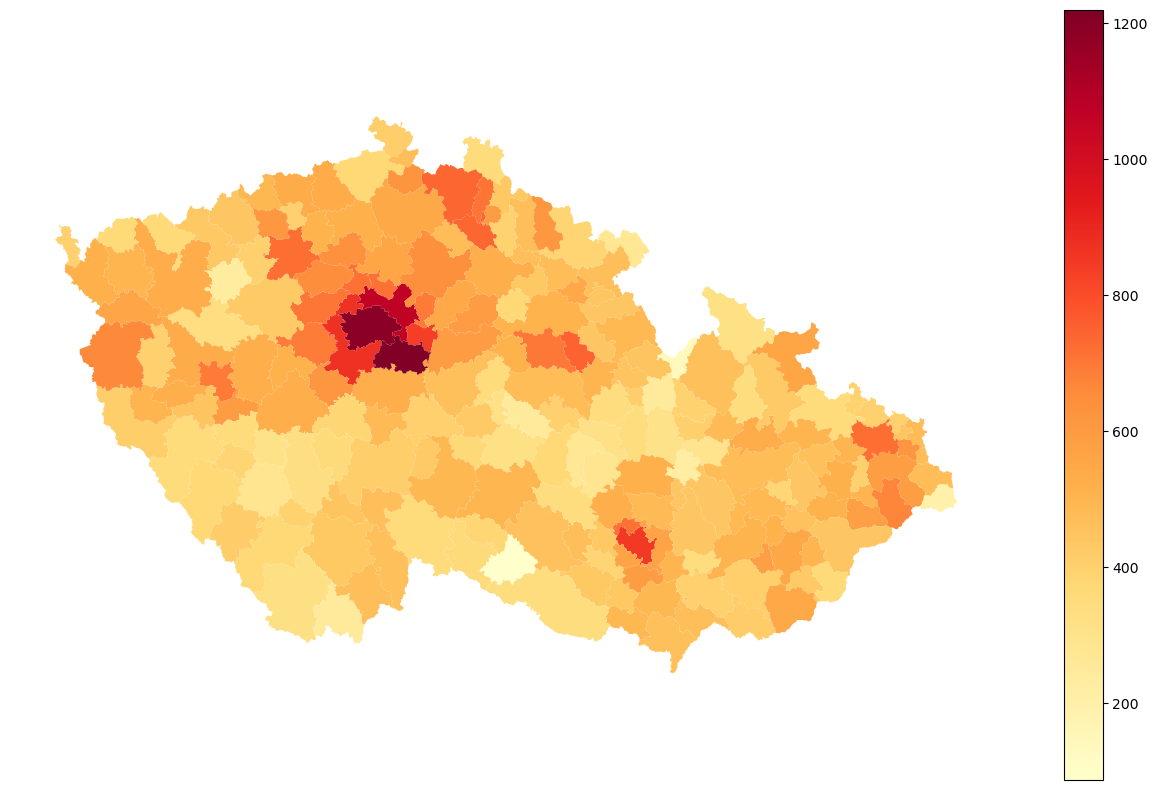

In [367]:
orp.plot("average_fee", figsize=(16,10),legend=True,cmap="YlOrRd").set_axis_off()

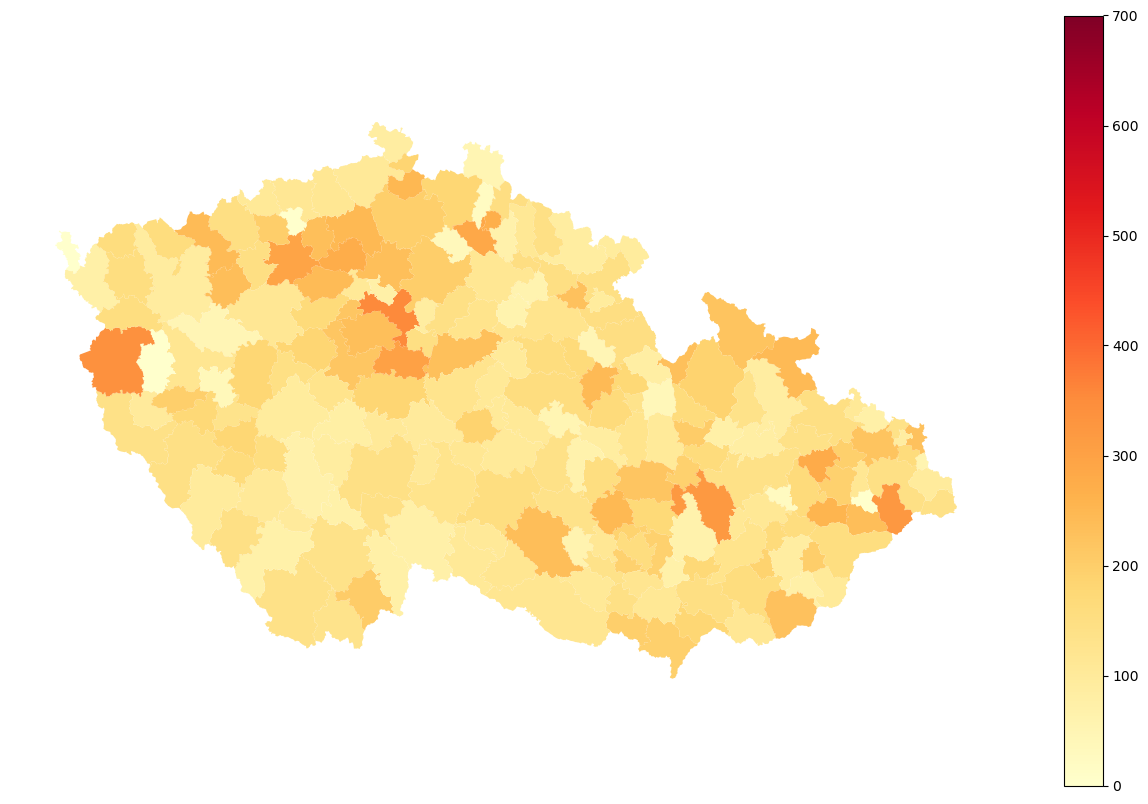

In [368]:
orp.plot("std_fee",figsize=(16,10), vmax=700,legend=True,cmap="YlOrRd", k=6).set_axis_off()

In [369]:
skolky_body2.to_parquet("/Users/annabrazdova/default/kindergartens/geometrie/skolky_body_validated7.parquet")

In [370]:
skolky_body2["monthly_fe"].notna().sum()

np.int64(1812)

In [371]:
skolky_body2

,Zřizovate,Kraj,Název_ORP,ORP,WWW,Plný_náz,monthly_fe,geometry
RED_IZO,,,,,,,,
600005399.0,2.0,Hlavní město Praha,Hlavní město Praha,1100.0,http://www.ksidlisti.cz,"Škola Kavčí hory - Mateřská škola, Základní šk...",NaN,POINT (-743268.308 -1047032.287)
600025713.0,2.0,Kraj Vysočina,Třebíč,6113.0,www.spmstrebic.cz,Speciální mateřská škola Třebíč,NaN,POINT (-650746.181 -1153587.129)
600035140.0,2.0,Hlavní město Praha,Hlavní město Praha,1100.0,www.msletenska.cz,Mateřská škola Letenská,1000.0,POINT (-744048.525 -1042979.657)
600035158.0,2.0,Hlavní město Praha,Hlavní město Praha,1100.0,http://www.msmasna.cz,Mateřská škola Masná,NaN,POINT (-742975.837 -1043007.925)
600035174.0,2.0,Hlavní město Praha,Hlavní město Praha,1100.0,www.msrevolucni.cz,Mateřská škola Revoluční,1140.0,POINT (-742655.357 -1043955.511)
...,...,...,...,...,...,...,...,...
691017166.0,2.0,Moravskoslezský kraj,Krnov,8114.0,https://www.msliptan.cz/,"Mateřská škola Liptaň, příspěvková organizace",NaN,POINT (-515723.822 -1054507.795)
691017379.0,2.0,Hlavní město Praha,Hlavní město Praha,1100.0,www.zselektra.cz,"Základní škola a Mateřská škola Elektra, přísp...",1350.0,POINT (-736293.779 -1041437.02)
691017387.0,2.0,Ústecký kraj,Lovosice,4208.0,https://ms-sedmikraskavrbicany.webnode.cz/,Mateřská škola Sedmikráska Vrbičany - příspěvk...,1000.0,POINT (-760424.597 -998305.23)
